In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [7]:
df = pd.read_csv('ecommerce_data.csv', encoding='latin-1')
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
import os
print(os.getcwd())

C:\Users\Binni\OneDrive\Desktop\customer-segmentation-rfm


In [4]:
print(os.listdir())

['.git', '.ipynb_checkpoints', 'customer_segmentation.ipynb', 'ecommerce_data.csv.csv', 'README.md']


In [6]:
import os
os.rename('ecommerce_data.csv.csv', 'ecommerce_data.csv')
print(os.listdir())

['.git', '.ipynb_checkpoints', 'customer_segmentation.ipynb', 'ecommerce_data.csv', 'README.md']


In [8]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
# Remove rows with missing CustomerID (can't segment without knowing the customer)
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].str.startswith('C')]

# Remove negative quantities and zero/negative prices
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.shape)
print("Data cleaned successfully!")

(397884, 8)
Data cleaned successfully!


In [10]:
# Set reference date (one day after last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Calculate RFM metrics per customer
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head())

(4338, 4)
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40


In [11]:
# Score each customer 1-4 on each RFM dimension
# Recency: lower days = better (score 4), higher days = worse (score 1)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])

# Frequency: higher = better (score 4)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])

# Monetary: higher = better (score 4)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

# Combine scores into one RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm[['CustomerID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']].head(10))

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0       12346      326          1  77183.60       1       1       4       114
1       12347        2          7   4310.00       4       4       4       444
2       12348       75          4   1797.24       2       3       4       234
3       12349       19          1   1757.55       3       1       4       314
4       12350      310          1    334.40       1       1       2       112
5       12352       36          8   2506.04       3       4       4       344
6       12353      204          1     89.00       1       1       1       111
7       12354      232          1   1079.40       1       1       3       113
8       12355      214          1    459.40       1       1       2       112
9       12356       23          3   2811.43       3       3       4       334


In [12]:
# Define customer segments
def segment_customer(row):
    r = int(str(row['R_Score']))
    f = int(str(row['F_Score']))
    m = int(str(row['M_Score']))
    
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 2 and f == 1:
        return 'Need Attention'
    elif r == 1 and f >= 2:
        return 'Cant Lose Them'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Champions              1319
At Risk                 759
Loyal Customers         610
Cant Lose Them          565
Lost Customers          519
Need Attention          307
Potential Loyalists     259
Name: count, dtype: int64


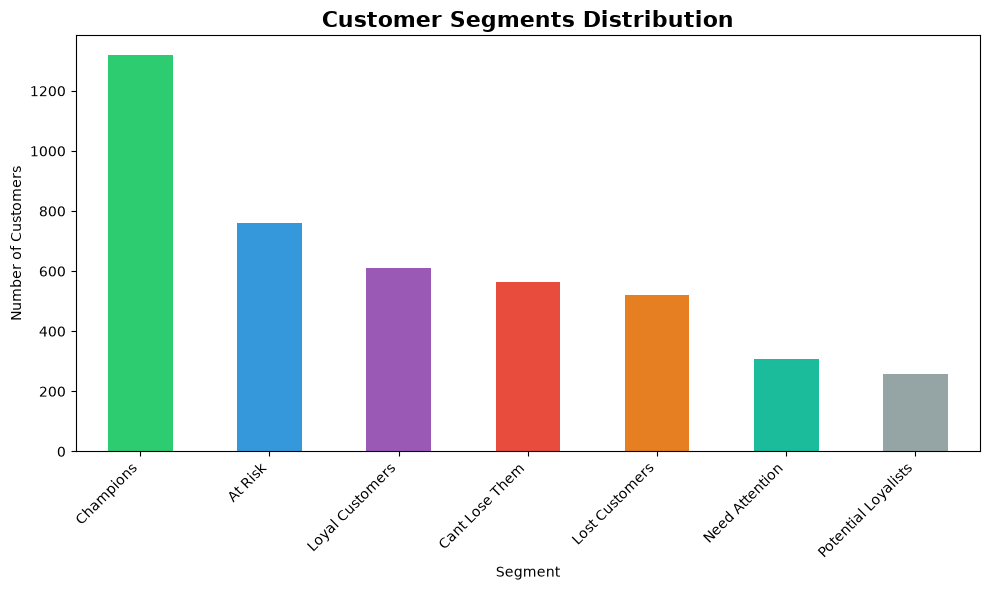

In [13]:
plt.figure(figsize=(10,6))
colors = ['#2ecc71','#3498db','#9b59b6','#e74c3c','#e67e22','#1abc9c','#95a5a6']
rfm['Segment'].value_counts().plot(kind='bar', color=colors)
plt.title('Customer Segments Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

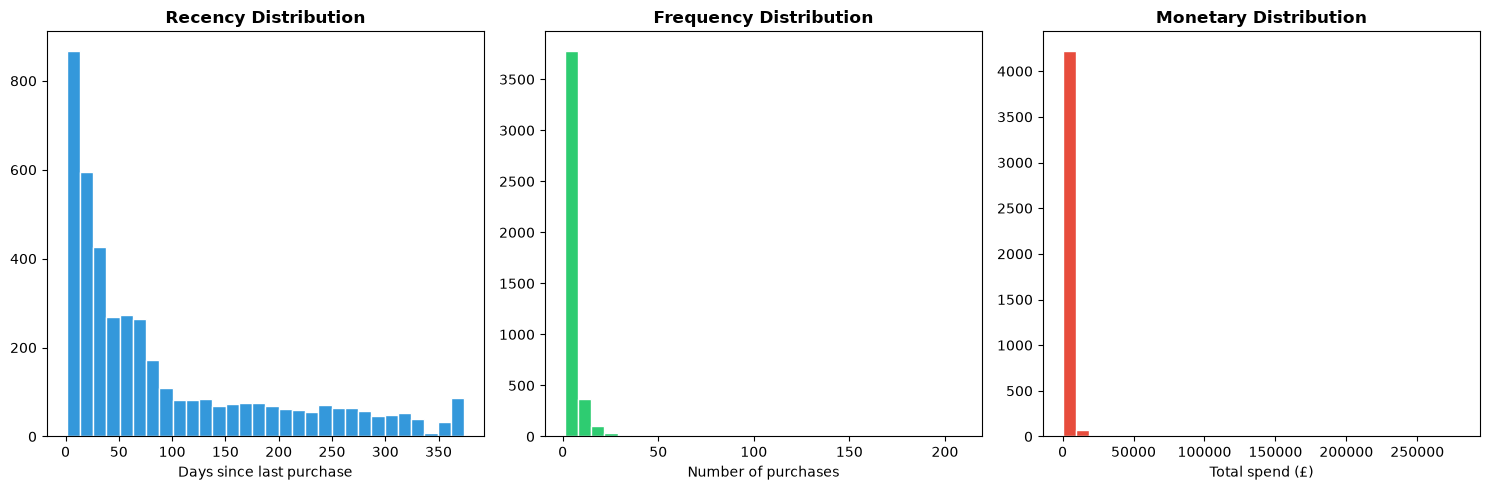

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].hist(rfm['Recency'], bins=30, color='#3498db', edgecolor='white')
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm['Frequency'], bins=30, color='#2ecc71', edgecolor='white')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of purchases')

axes[2].hist(rfm['Monetary'], bins=30, color='#e74c3c', edgecolor='white')
axes[2].set_title('Monetary Distribution', fontweight='bold')
axes[2].set_xlabel('Total spend (£)')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use RFM values for clustering
rfm_clustering = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Scale the data (important for K-Means)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clustering)

print("Data scaled successfully!")
print(f"Shape: {rfm_scaled.shape}")

Data scaled successfully!
Shape: (4338, 3)


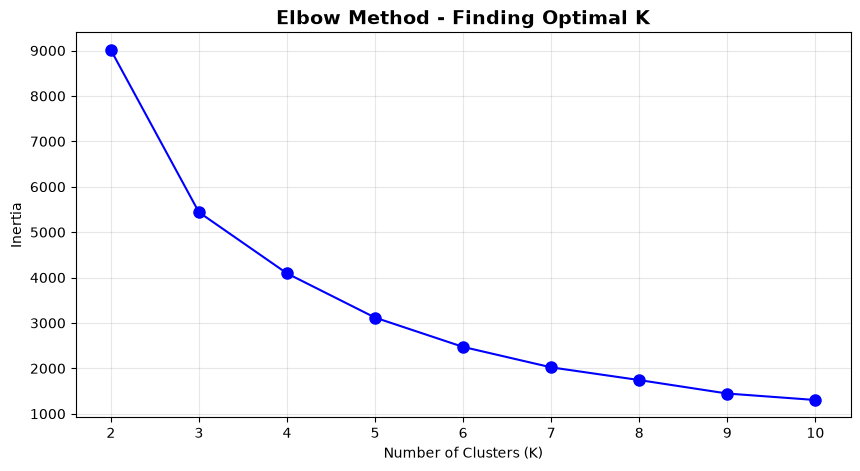

In [16]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Finding Optimal K', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# See cluster sizes
print(rfm['Cluster'].value_counts())

# See average RFM values per cluster
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print("\nCluster Summary:")
print(cluster_summary)

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

Cluster Summary:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


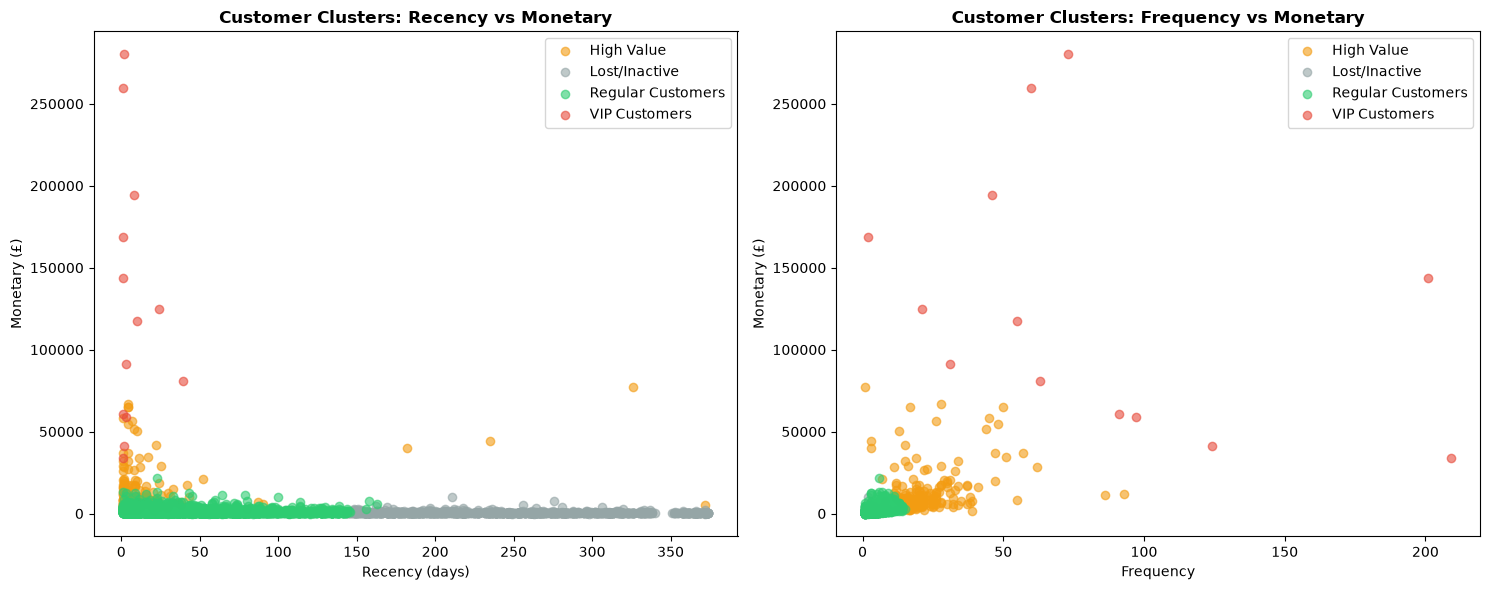

In [18]:
# Label clusters with business names
cluster_labels = {
    2: 'VIP Customers',
    3: 'High Value',
    0: 'Regular Customers',
    1: 'Lost/Inactive'
}
rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(15,6))

colors = {'VIP Customers':'#e74c3c', 'High Value':'#f39c12', 
          'Regular Customers':'#2ecc71', 'Lost/Inactive':'#95a5a6'}

# Recency vs Monetary
for label, group in rfm.groupby('Cluster_Label'):
    axes[0].scatter(group['Recency'], group['Monetary'], 
                   label=label, alpha=0.6, color=colors[label])
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Customer Clusters: Recency vs Monetary', fontweight='bold')
axes[0].legend()

# Frequency vs Monetary
for label, group in rfm.groupby('Cluster_Label'):
    axes[1].scatter(group['Frequency'], group['Monetary'], 
                   label=label, alpha=0.6, color=colors[label])
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Customer Clusters: Frequency vs Monetary', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
print("=" * 55)
print("CUSTOMER SEGMENTATION ANALYSIS - KEY FINDINGS")
print("=" * 55)

print(f"\nTotal Customers Analyzed: {len(rfm):,}")
print(f"Total Transactions: 541,909")
print(f"Date Range: Dec 2010 - Dec 2011")

print("\n--- CLUSTER BREAKDOWN ---")
for label in ['VIP Customers', 'High Value', 'Regular Customers', 'Lost/Inactive']:
    count = len(rfm[rfm['Cluster_Label'] == label])
    pct = count/len(rfm)*100
    avg_spend = rfm[rfm['Cluster_Label'] == label]['Monetary'].mean()
    print(f"{label}: {count} customers ({pct:.1f}%) | Avg Spend: £{avg_spend:,.2f}")

CUSTOMER SEGMENTATION ANALYSIS - KEY FINDINGS

Total Customers Analyzed: 4,338
Total Transactions: 541,909
Date Range: Dec 2010 - Dec 2011

--- CLUSTER BREAKDOWN ---
VIP Customers: 13 customers (0.3%) | Avg Spend: £127,338.31
High Value: 204 customers (4.7%) | Avg Spend: £12,709.09
Regular Customers: 3054 customers (70.4%) | Avg Spend: £1,359.05
Lost/Inactive: 1067 customers (24.6%) | Avg Spend: £480.62


## Key Business Insights & Recommendations

**VIP Customers (13 customers):** These 13 customers generate extraordinary revenue 
averaging £127,338 each. Assign dedicated account managers and offer exclusive 
loyalty rewards to retain them at all costs.

**High Value Customers (204 customers):** Recent and frequent buyers with strong spend. 
Target with premium product launches and early access offers to move them toward VIP status.

**Regular Customers (3,054 customers - 70%):** The bulk of the customer base. 
Focus on increasing purchase frequency through loyalty programs and personalized recommendations.

**Lost/Inactive Customers (1,067 customers):** Last purchased 248 days ago on average. 
Launch win-back campaigns with special discounts and "We miss you" email sequences.